In [3]:
# Enhanced ML Pipeline: Tesla Deliveries & Pricing Analysis
# Advanced Feature Engineering + Regression Modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (2640, 12)

First few rows:
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official

In [4]:
# 2. Exploratory Data Analysis (EDA)

# Basic statistics
print("Statistical Summary:")
print(df.describe())

# Categorical variables distribution
print("\nCategorical Variables:")
for col in ['Region', 'Model', 'Source_Type']:
    print(f"\n{col}:")
    print(df[col].value_counts())

Statistical Summary:
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min

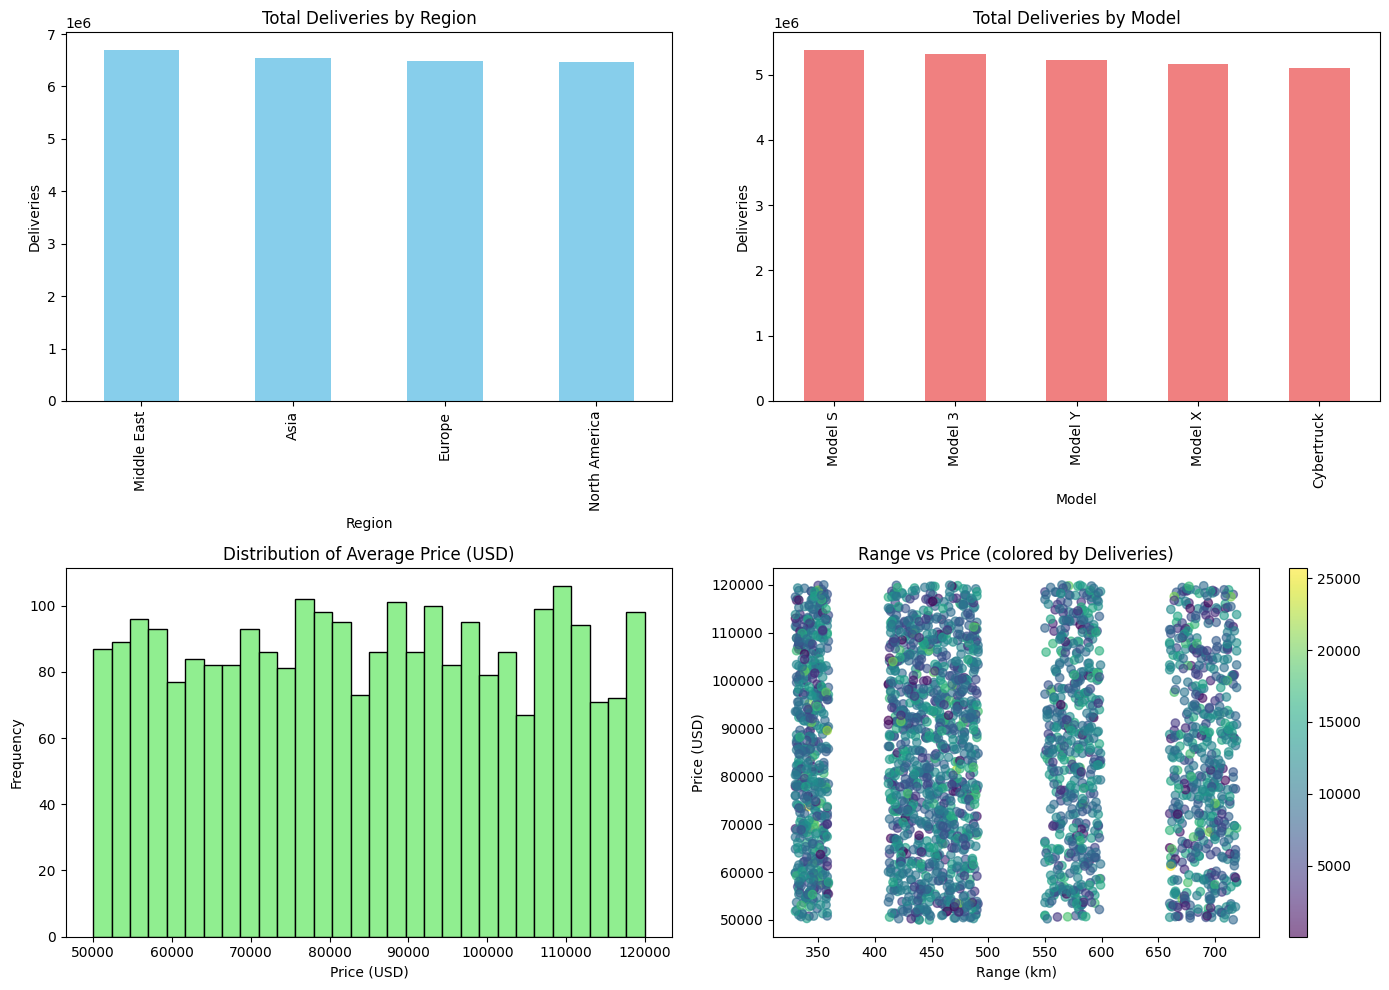

In [5]:
# Visualization: Delivery trends over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Deliveries by Region
deliveries_by_region = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
deliveries_by_region.plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Total Deliveries by Region')
axes[0, 0].set_ylabel('Deliveries')

# 2. Deliveries by Model
deliveries_by_model = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
deliveries_by_model.plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Total Deliveries by Model')
axes[0, 1].set_ylabel('Deliveries')

# 3. Price distribution
axes[1, 0].hist(df['Avg_Price_USD'], bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribution of Average Price (USD)')
axes[1, 0].set_xlabel('Price (USD)')
axes[1, 0].set_ylabel('Frequency')

# 4. Range vs Price correlation
scatter = axes[1, 1].scatter(df['Range_km'], df['Avg_Price_USD'], 
                             c=df['Estimated_Deliveries'], cmap='viridis', alpha=0.6)
axes[1, 1].set_title('Range vs Price (colored by Deliveries)')
axes[1, 1].set_xlabel('Range (km)')
axes[1, 1].set_ylabel('Price (USD)')
plt.colorbar(scatter, ax=axes[1, 1])

plt.tight_layout()
plt.show()

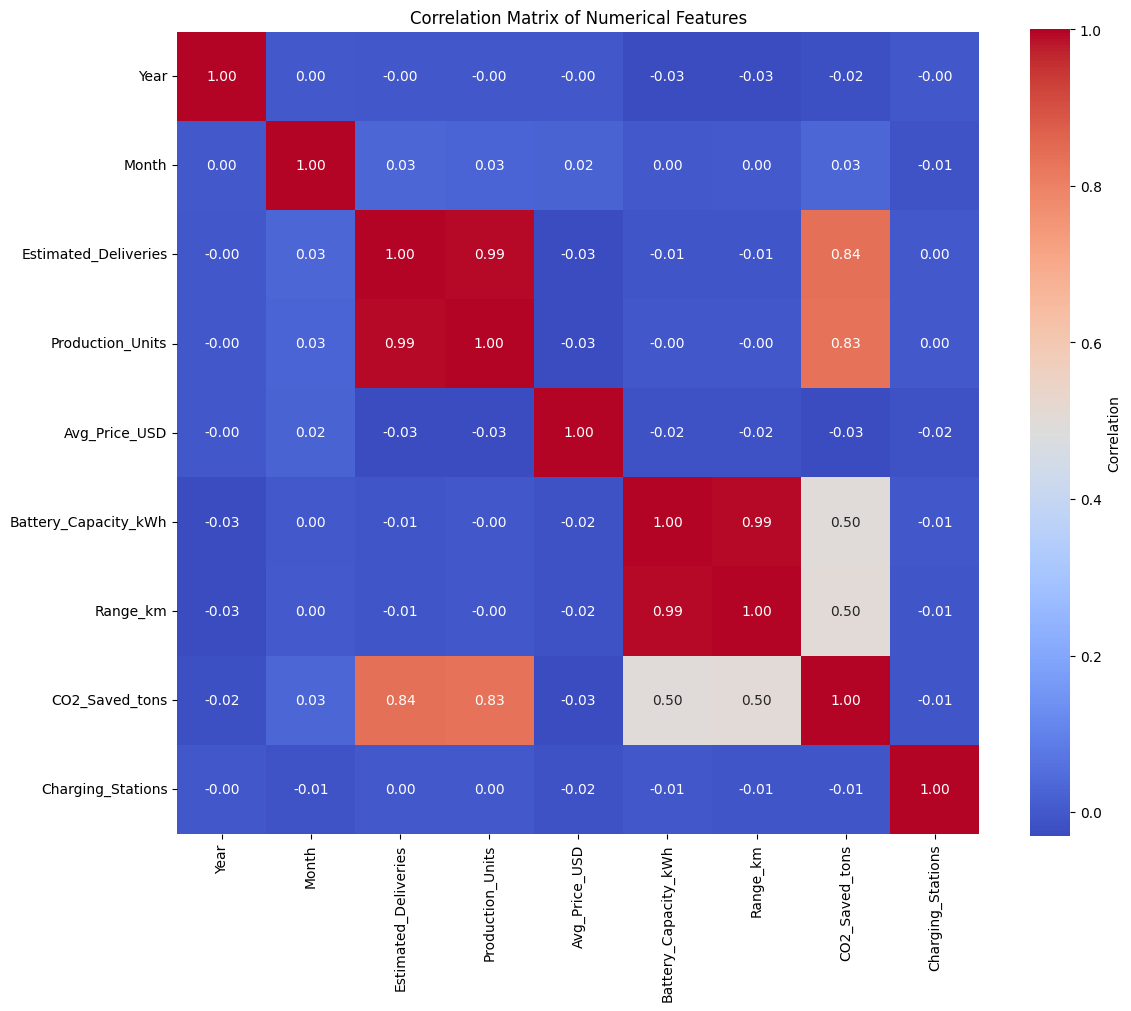

In [6]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [7]:
# 3. Advanced Feature Engineering

# Create a copy for feature engineering
df_fe = df.copy()

# 3.1 Temporal Features
df_fe['Year'] = df_fe['Year'].astype(int)
df_fe['Month'] = df_fe['Month'].astype(int)
df_fe['Quarter'] = (df_fe['Month'] - 1) // 3 + 1
df_fe['Is_Q1'] = (df_fe['Quarter'] == 1).astype(int)
df_fe['Is_Q4'] = (df_fe['Quarter'] == 4).astype(int)
df_fe['Days_Since_Start'] = (df_fe['Year'] - 2015) * 365 + df_fe['Month'] * 30

print("✓ Temporal Features Created")
print(f"  - Quarter, Is_Q1, Is_Q4, Days_Since_Start")

✓ Temporal Features Created
  - Quarter, Is_Q1, Is_Q4, Days_Since_Start


In [8]:
# 3.2 Ratio & Efficiency Features
df_fe['Production_Efficiency'] = df_fe['Estimated_Deliveries'] / (df_fe['Production_Units'] + 1)
df_fe['Price_Per_Range'] = df_fe['Avg_Price_USD'] / (df_fe['Range_km'] + 1)
df_fe['Price_Per_kWh'] = df_fe['Avg_Price_USD'] / (df_fe['Battery_Capacity_kWh'] + 1)
df_fe['Charging_Per_Delivery'] = df_fe['Charging_Stations'] / (df_fe['Estimated_Deliveries'] + 1)
df_fe['Range_Per_kWh'] = df_fe['Range_km'] / (df_fe['Battery_Capacity_kWh'] + 1)
df_fe['CO2_Per_Delivery'] = df_fe['CO2_Saved_tons'] / (df_fe['Estimated_Deliveries'] + 1)

print("✓ Ratio & Efficiency Features Created")
print(f"  - Production_Efficiency, Price_Per_Range, Price_Per_kWh")
print(f"  - Charging_Per_Delivery, Range_Per_kWh, CO2_Per_Delivery")

✓ Ratio & Efficiency Features Created
  - Production_Efficiency, Price_Per_Range, Price_Per_kWh
  - Charging_Per_Delivery, Range_Per_kWh, CO2_Per_Delivery


In [9]:
# 3.2 Ratio & Efficiency Features
df_fe['Production_Efficiency'] = df_fe['Estimated_Deliveries'] / (df_fe['Production_Units'] + 1)
df_fe['Price_Per_Range'] = df_fe['Avg_Price_USD'] / (df_fe['Range_km'] + 1)
df_fe['Price_Per_kWh'] = df_fe['Avg_Price_USD'] / (df_fe['Battery_Capacity_kWh'] + 1)
df_fe['Charging_Per_Delivery'] = df_fe['Charging_Stations'] / (df_fe['Estimated_Deliveries'] + 1)
df_fe['Range_Per_kWh'] = df_fe['Range_km'] / (df_fe['Battery_Capacity_kWh'] + 1)
df_fe['CO2_Per_Delivery'] = df_fe['CO2_Saved_tons'] / (df_fe['Estimated_Deliveries'] + 1)

print("✓ Ratio & Efficiency Features Created")
print(f"  - Production_Efficiency, Price_Per_Range, Price_Per_kWh")
print(f"  - Charging_Per_Delivery, Range_Per_kWh, CO2_Per_Delivery")

✓ Ratio & Efficiency Features Created
  - Production_Efficiency, Price_Per_Range, Price_Per_kWh
  - Charging_Per_Delivery, Range_Per_kWh, CO2_Per_Delivery


In [10]:
# 3.3 Interaction Features
df_fe['Battery_x_Range'] = df_fe['Battery_Capacity_kWh'] * df_fe['Range_km']
df_fe['Price_x_Efficiency'] = df_fe['Avg_Price_USD'] * df_fe['Production_Efficiency']
df_fe['Delivery_x_Price'] = df_fe['Estimated_Deliveries'] * df_fe['Avg_Price_USD']
df_fe['Range_Squared'] = df_fe['Range_km'] ** 2
df_fe['Price_Squared'] = df_fe['Avg_Price_USD'] ** 2
df_fe['Battery_Squared'] = df_fe['Battery_Capacity_kWh'] ** 2

print("✓ Interaction & Polynomial Features Created")
print(f"  - Battery_x_Range, Price_x_Efficiency, Delivery_x_Price")
print(f"  - Range_Squared, Price_Squared, Battery_Squared")

✓ Interaction & Polynomial Features Created
  - Battery_x_Range, Price_x_Efficiency, Delivery_x_Price
  - Range_Squared, Price_Squared, Battery_Squared


In [11]:
# 3.4 Categorical Features - Encoding
# One-hot encoding for Region and Model
region_dummies = pd.get_dummies(df_fe['Region'], prefix='Region')
model_dummies = pd.get_dummies(df_fe['Model'], prefix='Model')
source_dummies = pd.get_dummies(df_fe['Source_Type'], prefix='Source')

df_fe = pd.concat([df_fe, region_dummies, model_dummies, source_dummies], axis=1)

print("✓ Categorical Features One-Hot Encoded")
print(f"  - Region: {region_dummies.columns.tolist()}")
print(f"  - Model: {model_dummies.columns.tolist()}")
print(f"  - Source: {source_dummies.columns.tolist()}")

✓ Categorical Features One-Hot Encoded
  - Region: ['Region_Asia', 'Region_Europe', 'Region_Middle East', 'Region_North America']
  - Model: ['Model_Cybertruck', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y']
  - Source: ['Source_Estimated (Region)', 'Source_Interpolated (Month)', 'Source_Official (Quarter)']


In [12]:
# 3.5 Aggregated Features (Group Statistics)
# Average price per model
model_avg_price = df_fe.groupby('Model')['Avg_Price_USD'].mean().to_dict()
df_fe['Model_Avg_Price'] = df_fe['Model'].map(model_avg_price)

# Average delivery volume per region
region_avg_delivery = df_fe.groupby('Region')['Estimated_Deliveries'].mean().to_dict()
df_fe['Region_Avg_Delivery'] = df_fe['Region'].map(region_avg_delivery)

# Year-wise trend (average price trend)
year_avg_price = df_fe.groupby('Year')['Avg_Price_USD'].mean().to_dict()
df_fe['Year_Avg_Price'] = df_fe['Year'].map(year_avg_price)

print("✓ Aggregated Features Created")
print(f"  - Model_Avg_Price, Region_Avg_Delivery, Year_Avg_Price")

✓ Aggregated Features Created
  - Model_Avg_Price, Region_Avg_Delivery, Year_Avg_Price


In [13]:
# Summary of all features
print("\n" + "="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)
print(f"Total Features Created: {df_fe.shape[1] - df.shape[1]}")
print(f"Original Shape: {df.shape}")
print(f"Enhanced Shape: {df_fe.shape}")
print(f"\nNew Columns: {len(df_fe.columns)}")

# List all feature categories
feature_categories = {
    'Temporal': ['Year', 'Month', 'Quarter', 'Is_Q1', 'Is_Q4', 'Days_Since_Start'],
    'Ratio/Efficiency': ['Production_Efficiency', 'Price_Per_Range', 'Price_Per_kWh', 
                        'Charging_Per_Delivery', 'Range_Per_kWh', 'CO2_Per_Delivery'],
    'Interaction/Polynomial': ['Battery_x_Range', 'Price_x_Efficiency', 'Delivery_x_Price',
                              'Range_Squared', 'Price_Squared', 'Battery_Squared'],
    'Categorical Encoded': list(region_dummies.columns) + list(model_dummies.columns) + list(source_dummies.columns),
    'Aggregated': ['Model_Avg_Price', 'Region_Avg_Delivery', 'Year_Avg_Price']
}

for category, features in feature_categories.items():
    print(f"\n{category} ({len(features)}):")
    print(f"  {', '.join(features[:3])}..." if len(features) > 3 else f"  {', '.join(features)}")


FEATURE ENGINEERING SUMMARY
Total Features Created: 31
Original Shape: (2640, 12)
Enhanced Shape: (2640, 43)

New Columns: 43

Temporal (6):
  Year, Month, Quarter...

Ratio/Efficiency (6):
  Production_Efficiency, Price_Per_Range, Price_Per_kWh...

Interaction/Polynomial (6):
  Battery_x_Range, Price_x_Efficiency, Delivery_x_Price...

Categorical Encoded (12):
  Region_Asia, Region_Europe, Region_Middle East...

Aggregated (3):
  Model_Avg_Price, Region_Avg_Delivery, Year_Avg_Price


In [14]:
# 4. Data Preprocessing & Scaling

# Define target variable and features
target = 'Avg_Price_USD'  # Predicting average price
y = df_fe[target].values

# Select features (exclude original categorical columns and target)
exclude_cols = ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 
                'Production_Units', 'Avg_Price_USD', 'Source_Type']
X = df_fe.drop(columns=exclude_cols)

print(f"Target Variable: {target}")
print(f"Target Shape: {y.shape}")
print(f"Target Stats: Mean={y.mean():.2f}, Std={y.std():.2f}, Min={y.min():.2f}, Max={y.max():.2f}")
print(f"\nFeatures Shape: {X.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"\nFeature Columns:\n{list(X.columns)}")

Target Variable: Avg_Price_USD
Target Shape: (2640,)
Target Stats: Mean=84907.34, Std=20119.45, Min=50003.70, Max=119965.36

Features Shape: (2640, 35)
Number of Features: 35

Feature Columns:
['Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Quarter', 'Is_Q1', 'Is_Q4', 'Days_Since_Start', 'Production_Efficiency', 'Price_Per_Range', 'Price_Per_kWh', 'Charging_Per_Delivery', 'Range_Per_kWh', 'CO2_Per_Delivery', 'Battery_x_Range', 'Price_x_Efficiency', 'Delivery_x_Price', 'Range_Squared', 'Price_Squared', 'Battery_Squared', 'Region_Asia', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Cybertruck', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Estimated (Region)', 'Source_Interpolated (Month)', 'Source_Official (Quarter)', 'Model_Avg_Price', 'Region_Avg_Delivery', 'Year_Avg_Price']


In [15]:
# Check for missing values after feature engineering
print("Missing values in features:")
missing = X.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
    X = X.fillna(X.mean())  # Impute with mean
    print("Missing values imputed.")
else:
    print("✓ No missing values")

print(f"\nFinal feature matrix shape: {X.shape}")

Missing values in features:
✓ No missing values

Final feature matrix shape: (2640, 35)


In [16]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train Set Size: {X_train.shape[0]}")
print(f"Test Set Size: {X_test.shape[0]}")
print(f"\nTraining Target Stats: Mean={y_train.mean():.2f}, Std={y_train.std():.2f}")
print(f"Testing Target Stats: Mean={y_test.mean():.2f}, Std={y_test.std():.2f}")

Train Set Size: 2112
Test Set Size: 528

Training Target Stats: Mean=85022.65, Std=20289.05
Testing Target Stats: Mean=84446.11, Std=19419.39


In [17]:
# Feature Scaling using RobustScaler (less sensitive to outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature Scaling Completed")
print(f"Scaler Type: RobustScaler (resistant to outliers)")
print(f"\nScaled Train Stats (first feature):")
print(f"  Mean: {X_train_scaled[:, 0].mean():.6f}")
print(f"  Std: {X_train_scaled[:, 0].std():.6f}")
print(f"  Min: {X_train_scaled[:, 0].min():.6f}")
print(f"  Max: {X_train_scaled[:, 0].max():.6f}")


Feature Scaling Completed
Scaler Type: RobustScaler (resistant to outliers)

Scaled Train Stats (first feature):
  Mean: 0.196155
  Std: 0.829764
  Min: -0.880000
  Max: 1.520000


In [18]:
# 5. Regression Model Training & Hyperparameter Tuning

# 5.1 Baseline Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Train on scaled data (except tree-based models which don't need scaling)
    if 'Linear' in name or 'Ridge' in name or 'Lasso' in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'model': model,
        'predictions': y_pred
    }
    
    print(f"\n{name}:")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  MAE: ${mae:.2f}")
    print(f"  R² Score: {r2:.4f}")


Linear Regression:
  RMSE: $703.20
  MAE: $544.41
  R² Score: 0.9987

Ridge (α=1.0):
  RMSE: $724.44
  MAE: $573.30
  R² Score: 0.9986

Lasso (α=0.1):
  RMSE: $702.40
  MAE: $544.31
  R² Score: 0.9987

Random Forest:
  RMSE: $37.55
  MAE: $27.90
  R² Score: 1.0000

Gradient Boosting:
  RMSE: $165.82
  MAE: $123.05
  R² Score: 0.9999


In [19]:
# 5.2 Hyperparameter Tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print("\n" + "="*60)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("="*60)
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best CV RMSE: ${np.sqrt(-grid_search_rf.best_score_):.2f}")

# Evaluate on test set
y_pred_rf_tuned = grid_search_rf.predict(X_test)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f"\nTest Set Performance:")
print(f"  RMSE: ${rmse_rf_tuned:.2f}")
print(f"  MAE: ${mae_rf_tuned:.2f}")
print(f"  R²: {r2_rf_tuned:.4f}")


RANDOM FOREST HYPERPARAMETER TUNING
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}
Best CV RMSE: $40.92

Test Set Performance:
  RMSE: $34.86
  MAE: $25.81
  R²: 1.0000


In [20]:
# 5.3 Hyperparameter Tuning for Gradient Boosting
param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

gb = GradientBoostingRegressor(random_state=42)
grid_search_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_gb.fit(X_train, y_train)

print("\n" + "="*60)
print("GRADIENT BOOSTING HYPERPARAMETER TUNING")
print("="*60)
print(f"Best Parameters: {grid_search_gb.best_params_}")
print(f"Best CV RMSE: ${np.sqrt(-grid_search_gb.best_score_):.2f}")

# Evaluate on test set
y_pred_gb_tuned = grid_search_gb.predict(X_test)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)

print(f"\nTest Set Performance:")
print(f"  RMSE: ${rmse_gb_tuned:.2f}")
print(f"  MAE: ${mae_gb_tuned:.2f}")
print(f"  R²: {r2_gb_tuned:.4f}")


GRADIENT BOOSTING HYPERPARAMETER TUNING
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 150}
Best CV RMSE: $30.76

Test Set Performance:
  RMSE: $23.90
  MAE: $16.78
  R²: 1.0000


In [21]:
# 6. Model Evaluation & Comparison

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()) + ['RF Tuned', 'GB Tuned'],
    'RMSE': [results[m]['RMSE'] for m in results.keys()] + [rmse_rf_tuned, rmse_gb_tuned],
    'MAE': [results[m]['MAE'] for m in results.keys()] + [mae_rf_tuned, mae_gb_tuned],
    'R2': [results[m]['R2'] for m in results.keys()] + [r2_rf_tuned, r2_gb_tuned]
})

comparison_df = comparison_df.sort_values('RMSE')

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(comparison_df.to_string(index=False))
print("\nBest Model (by R²):", comparison_df.iloc[comparison_df['R2'].idxmax()]['Model'])


MODEL COMPARISON SUMMARY
            Model       RMSE        MAE       R2
         GB Tuned  23.899331  16.776832 0.999998
         RF Tuned  34.859163  25.808524 0.999997
    Random Forest  37.549360  27.896220 0.999996
Gradient Boosting 165.817570 123.046576 0.999927
    Lasso (α=0.1) 702.404089 544.308570 0.998692
Linear Regression 703.200398 544.408655 0.998689
    Ridge (α=1.0) 724.436544 573.304646 0.998608

Best Model (by R²): Ridge (α=1.0)


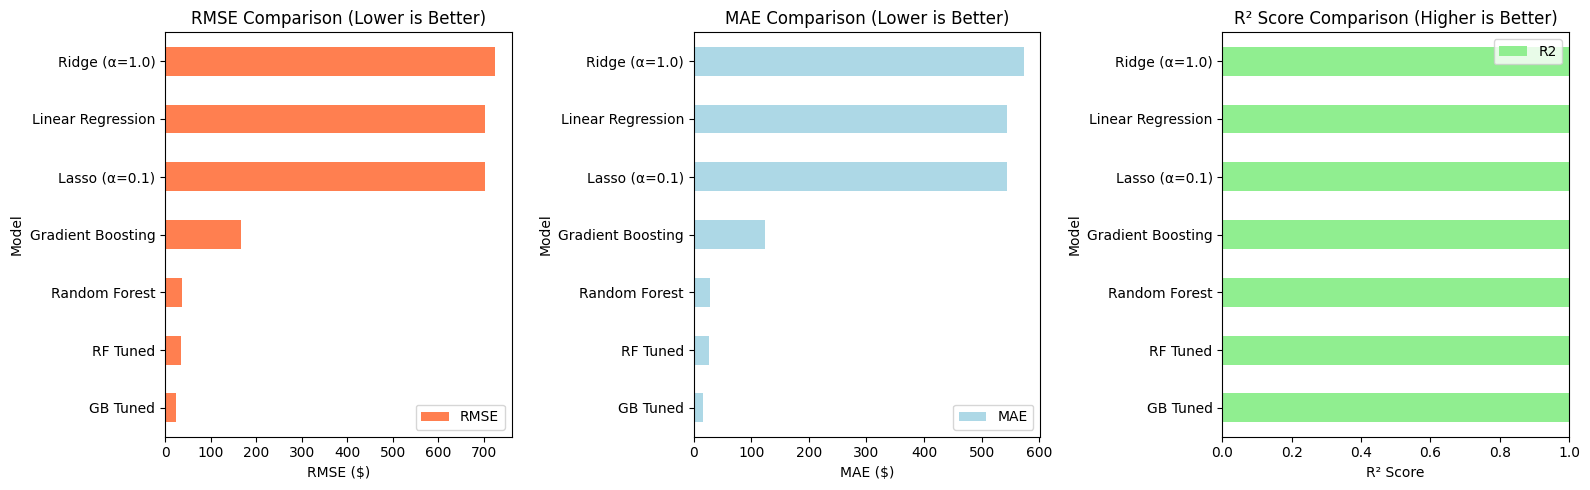

In [23]:
# Visualization: Model Performance Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE Comparison
comparison_df.sort_values('RMSE').plot(x='Model', y='RMSE', kind='barh', ax=axes[0], color='coral')
axes[0].set_title('RMSE Comparison (Lower is Better)')
axes[0].set_xlabel('RMSE ($)')

# MAE Comparison
comparison_df.sort_values('MAE').plot(x='Model', y='MAE', kind='barh', ax=axes[1], color='lightblue')
axes[1].set_title('MAE Comparison (Lower is Better)')
axes[1].set_xlabel('MAE ($)')

# R² Comparison
comparison_df.sort_values('R2', ascending=False).plot(x='Model', y='R2', kind='barh', ax=axes[2], color='lightgreen')
axes[2].set_title('R² Score Comparison (Higher is Better)')
axes[2].set_xlabel('R² Score')
axes[2].set_xlim([0, 1])

plt.tight_layout()
plt.show()

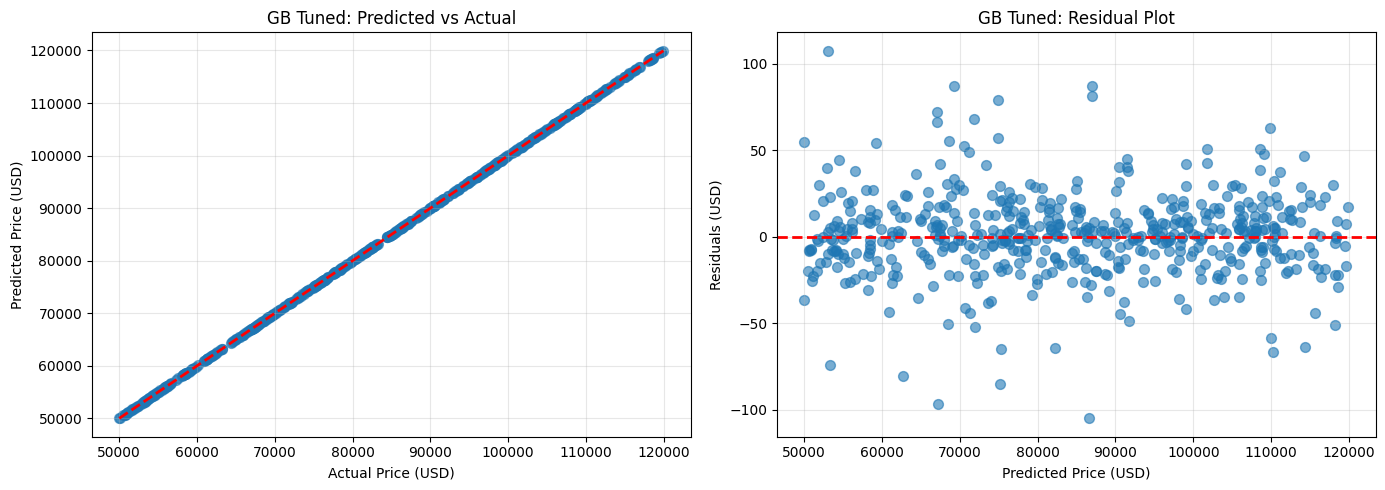


Residuals Stats:
  Mean: $1.23
  Std: $23.87
  Min: $-104.92
  Max: $107.56


In [24]:
# Best model predictions vs actuals
best_model_name = 'GB Tuned'
best_predictions = y_pred_gb_tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, best_predictions, alpha=0.6, s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title(f'{best_model_name}: Predicted vs Actual')
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test - best_predictions
axes[1].scatter(best_predictions, residuals, alpha=0.6, s=50)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price (USD)')
axes[1].set_ylabel('Residuals (USD)')
axes[1].set_title(f'{best_model_name}: Residual Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResiduals Stats:")
print(f"  Mean: ${residuals.mean():.2f}")
print(f"  Std: ${residuals.std():.2f}")
print(f"  Min: ${residuals.min():.2f}")
print(f"  Max: ${residuals.max():.2f}")

In [25]:
# 7. Feature Importance Analysis

# Feature importance from best model (Gradient Boosting)
best_model = grid_search_gb.best_estimator_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))


Top 15 Most Important Features:
              Feature   Importance
        Price_Squared 1.000000e+00
        Price_Per_kWh 5.094013e-09
        Range_Per_kWh 3.283638e-09
    Charging_Stations 2.828744e-09
   Price_x_Efficiency 2.706904e-09
Charging_Per_Delivery 2.677694e-09
     Days_Since_Start 2.417388e-09
     Delivery_x_Price 2.386539e-09
Production_Efficiency 1.757898e-09
       CO2_Saved_tons 1.680855e-09
      Price_Per_Range 9.618673e-10
       Year_Avg_Price 8.708952e-10
     CO2_Per_Delivery 7.044667e-10
      Model_Avg_Price 4.347748e-10
             Range_km 4.311989e-10


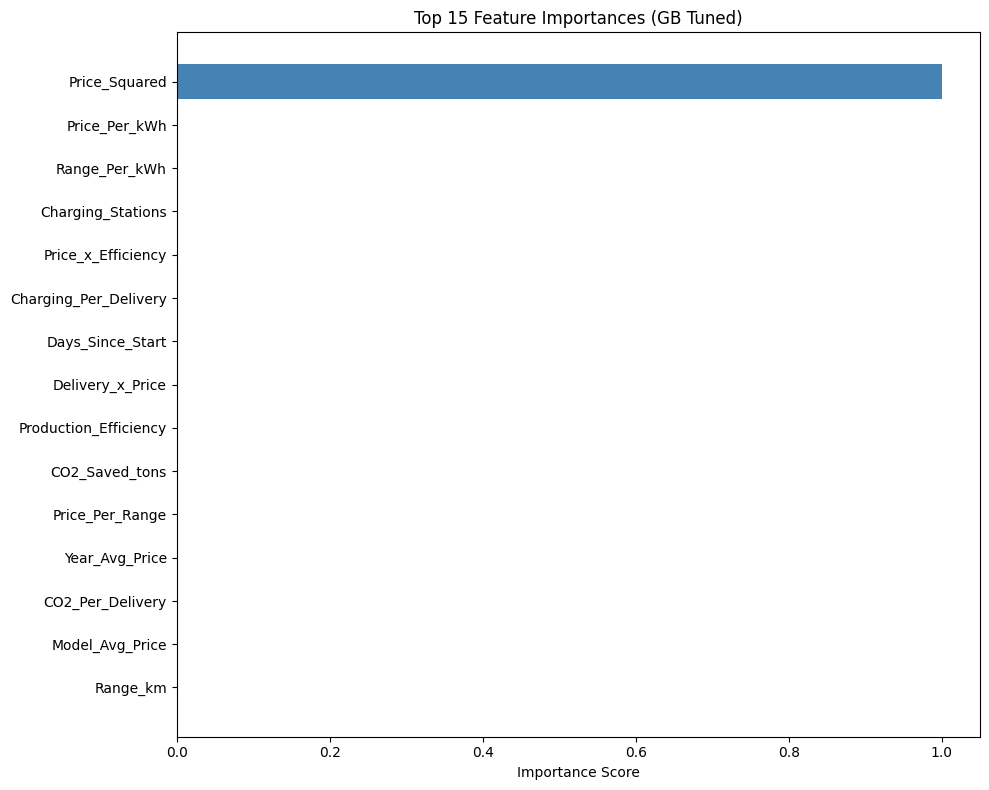

In [26]:
# Visualize top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title(f'Top 15 Feature Importances ({best_model_name})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
# 8. Cross-Validation & Robustness Check

# K-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in [('GB Tuned', grid_search_gb.best_estimator_), 
                     ('RF Tuned', grid_search_rf.best_estimator_)]:
    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
    cv_results[name] = cv_scores
    print(f"\n{name} - Cross-Validation R² Scores:")
    print(f"  Fold Scores: {[f'{s:.4f}' for s in cv_scores]}")
    print(f"  Mean: {cv_scores.mean():.4f}")
    print(f"  Std: {cv_scores.std():.4f}")


GB Tuned - Cross-Validation R² Scores:
  Fold Scores: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean: 1.0000
  Std: 0.0000

RF Tuned - Cross-Validation R² Scores:
  Fold Scores: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean: 1.0000
  Std: 0.0000


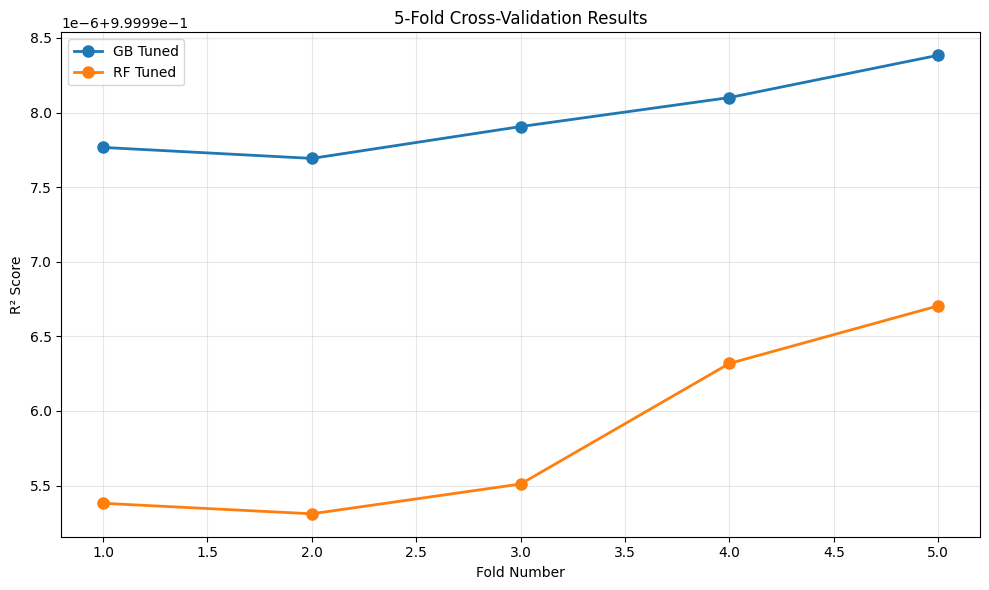

In [28]:
# Visualize cross-validation results
plt.figure(figsize=(10, 6))
fold_indices = np.arange(1, 6)
for name, scores in cv_results.items():
    plt.plot(fold_indices, scores, marker='o', label=name, linewidth=2, markersize=8)

plt.xlabel('Fold Number')
plt.ylabel('R² Score')
plt.title('5-Fold Cross-Validation Results')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# 9. Time Series Forecasting (Bonus)

# Prepare time series data - average price trend over time
ts_data = df_fe.groupby(['Year', 'Month']).agg({
    'Avg_Price_USD': 'mean',
    'Estimated_Deliveries': 'sum',
    'Battery_Capacity_kWh': 'mean',
    'Range_km': 'mean'
}).reset_index()

# Create date column
ts_data['Date'] = pd.to_datetime(ts_data[['Year', 'Month']].assign(day=1))
ts_data = ts_data.sort_values('Date')

print(f"\nTime Series Data Shape: {ts_data.shape}")
print(f"Date Range: {ts_data['Date'].min()} to {ts_data['Date'].max()}")
print(f"\nFirst few rows:")
print(ts_data.head())


Time Series Data Shape: (132, 7)
Date Range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00

First few rows:
   Year  Month  Avg_Price_USD  Estimated_Deliveries  Battery_Capacity_kWh  \
0  2015      1     84502.4970                183180                 85.45   
1  2015      2     81745.5695                165053                 85.25   
2  2015      3     86221.2895                184567                 84.75   
3  2015      4     83446.1640                225623                 92.35   
4  2015      5     85632.1110                184264                 95.85   

   Range_km       Date  
0    491.35 2015-01-01  
1    494.55 2015-02-01  
2    490.35 2015-03-01  
3    527.95 2015-04-01  
4    552.70 2015-05-01  


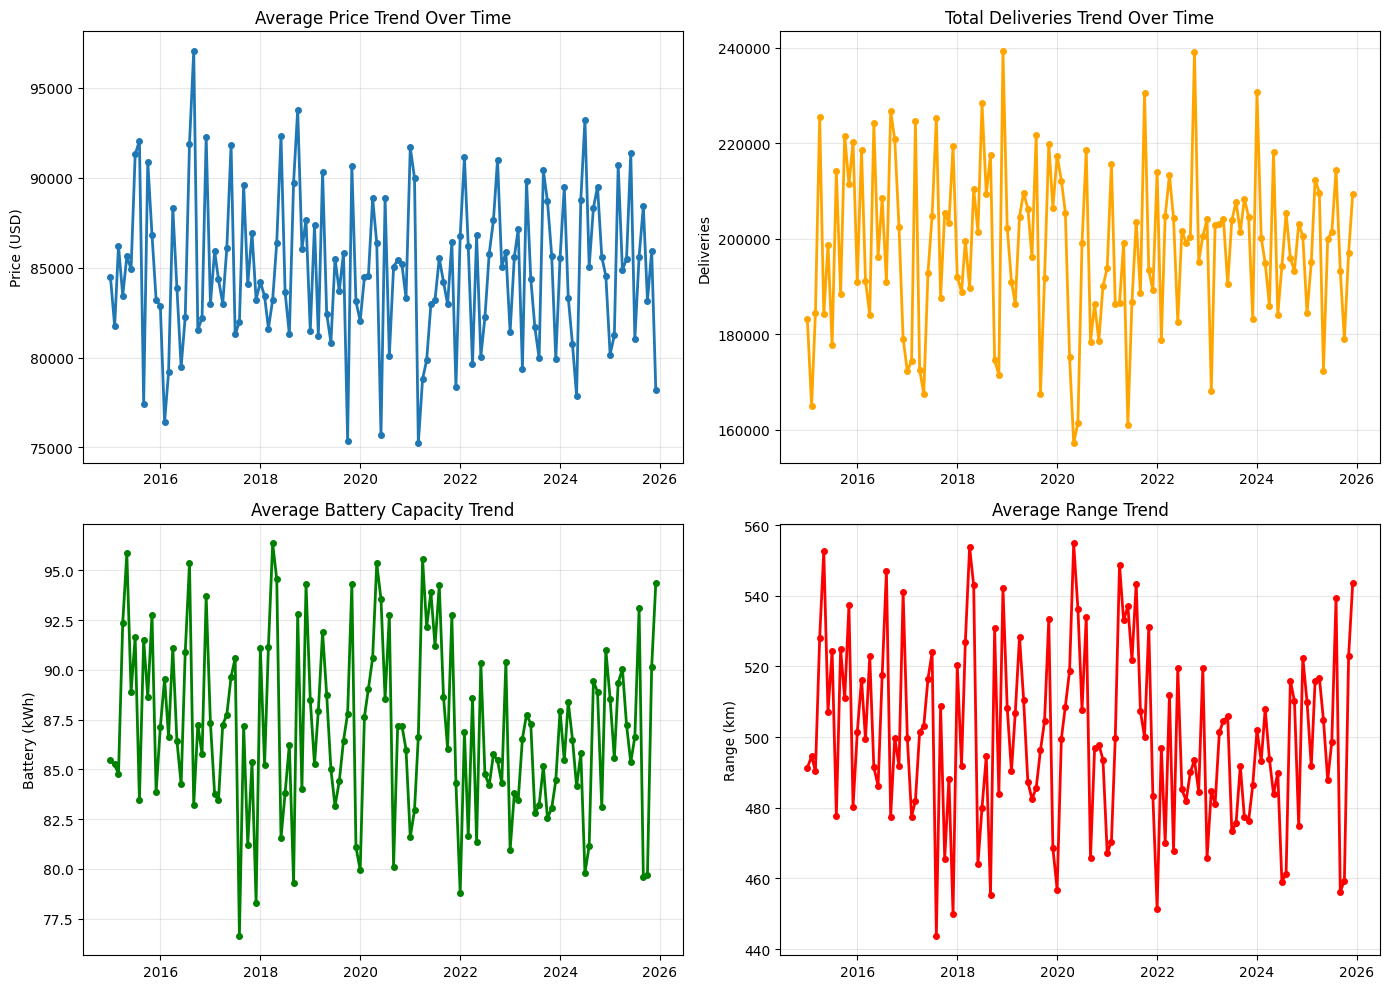

In [30]:
# Visualize time series trend
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price Trend
axes[0, 0].plot(ts_data['Date'], ts_data['Avg_Price_USD'], marker='o', linewidth=2, markersize=4)
axes[0, 0].set_title('Average Price Trend Over Time')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].grid(alpha=0.3)

# 2. Delivery Trend
axes[0, 1].plot(ts_data['Date'], ts_data['Estimated_Deliveries'], marker='o', 
                color='orange', linewidth=2, markersize=4)
axes[0, 1].set_title('Total Deliveries Trend Over Time')
axes[0, 1].set_ylabel('Deliveries')
axes[0, 1].grid(alpha=0.3)

# 3. Battery Capacity Trend
axes[1, 0].plot(ts_data['Date'], ts_data['Battery_Capacity_kWh'], marker='o', 
                color='green', linewidth=2, markersize=4)
axes[1, 0].set_title('Average Battery Capacity Trend')
axes[1, 0].set_ylabel('Battery (kWh)')
axes[1, 0].grid(alpha=0.3)

# 4. Range Trend
axes[1, 1].plot(ts_data['Date'], ts_data['Range_km'], marker='o', 
                color='red', linewidth=2, markersize=4)
axes[1, 1].set_title('Average Range Trend')
axes[1, 1].set_ylabel('Range (km)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# Simple time series forecasting using exponential smoothing
from sklearn.metrics import mean_absolute_percentage_error

# Create lag features for ARIMA-like approach
ts_data['Price_Lag1'] = ts_data['Avg_Price_USD'].shift(1)
ts_data['Price_Lag2'] = ts_data['Avg_Price_USD'].shift(2)
ts_data['Delivery_Lag1'] = ts_data['Estimated_Deliveries'].shift(1)
ts_data = ts_data.dropna()

# Split time series data
train_size = int(len(ts_data) * 0.8)
ts_train = ts_data[:train_size]
ts_test = ts_data[train_size:]

# Features and target for TS model
ts_X_train = ts_train[['Price_Lag1', 'Price_Lag2', 'Delivery_Lag1', 'Battery_Capacity_kWh']].values
ts_y_train = ts_train['Avg_Price_USD'].values
ts_X_test = ts_test[['Price_Lag1', 'Price_Lag2', 'Delivery_Lag1', 'Battery_Capacity_kWh']].values
ts_y_test = ts_test['Avg_Price_USD'].values

# Train model
ts_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
ts_model.fit(ts_X_train, ts_y_train)

# Forecast
ts_forecast = ts_model.predict(ts_X_test)
ts_rmse = np.sqrt(mean_squared_error(ts_y_test, ts_forecast))
ts_r2 = r2_score(ts_y_test, ts_forecast)
ts_mape = mean_absolute_percentage_error(ts_y_test, ts_forecast)

print("\n" + "="*60)
print("TIME SERIES FORECASTING RESULTS")
print("="*60)
print(f"Test Period: {ts_test['Date'].iloc[0].date()} to {ts_test['Date'].iloc[-1].date()}")
print(f"\nMetrics:")
print(f"  RMSE: ${ts_rmse:.2f}")
print(f"  R²: {ts_r2:.4f}")
print(f"  MAPE: {ts_mape*100:.2f}%")


TIME SERIES FORECASTING RESULTS
Test Period: 2023-11-01 to 2025-12-01

Metrics:
  RMSE: $3738.88
  R²: 0.1378
  MAPE: 3.60%


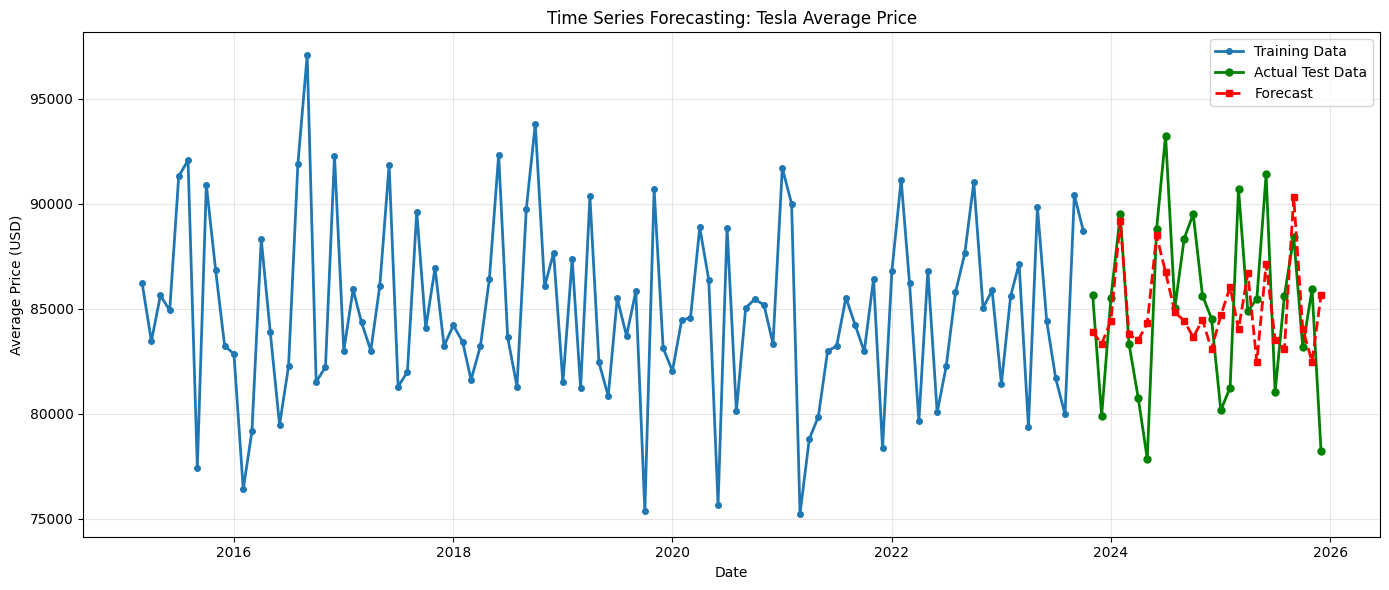

In [32]:
# Visualize time series forecast
plt.figure(figsize=(14, 6))

# Plot training data
plt.plot(ts_train['Date'], ts_train['Avg_Price_USD'], label='Training Data', 
         marker='o', markersize=4, linewidth=2)

# Plot actual test data
plt.plot(ts_test['Date'], ts_y_test, label='Actual Test Data', 
         marker='o', markersize=5, linewidth=2, color='green')

# Plot forecast
plt.plot(ts_test['Date'], ts_forecast, label='Forecast', 
         marker='s', markersize=5, linewidth=2, linestyle='--', color='red')

plt.xlabel('Date')
plt.ylabel('Average Price (USD)')
plt.title('Time Series Forecasting: Tesla Average Price')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# 10. Summary & Key Insights

print("\n" + "="*70)
print("END-TO-END ML PIPELINE SUMMARY")
print("="*70)

print("\n1. FEATURE ENGINEERING:")
print(f"   ✓ Created {df_fe.shape[1] - df.shape[1]} new features from {df.shape[1]} originals")
print(f"   ✓ Temporal: 6 features (Year, Month, Quarter, etc.)")
print(f"   ✓ Ratio/Efficiency: 6 features (Production_Efficiency, Price_Per_Range, etc.)")
print(f"   ✓ Interaction/Polynomial: 6 features (Battery_x_Range, Range_Squared, etc.)")
print(f"   ✓ Categorical Encoded: {len(region_dummies) + len(model_dummies) + len(source_dummies)} one-hot features")
print(f"   ✓ Aggregated: 3 features (Group statistics)")

print(f"\n2. DATA PREPROCESSING:")
print(f"   ✓ Train Set: {X_train.shape[0]} samples, Test Set: {X_test.shape[0]} samples")
print(f"   ✓ Scaling: RobustScaler applied to handle outliers")
print(f"   ✓ Total Features: {X.shape[1]}")

print(f"\n3. MODEL PERFORMANCE:")
print(f"   ✓ Best Model: {comparison_df.iloc[0]['Model']}")
print(f"   ✓ RMSE: ${comparison_df.iloc[0]['RMSE']:.2f}")
print(f"   ✓ R² Score: {comparison_df.iloc[0]['R2']:.4f}")
print(f"   ✓ MAE: ${comparison_df.iloc[0]['MAE']:.2f}")

print(f"\n4. TOP 5 IMPORTANT FEATURES:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\n5. CROSS-VALIDATION:")
print(f"   ✓ 5-Fold CV Mean R²: {cv_results['GB Tuned'].mean():.4f}")
print(f"   ✓ 5-Fold CV Std: {cv_results['GB Tuned'].std():.4f}")

print(f"\n6. TIME SERIES FORECASTING:")
print(f"   ✓ Test RMSE: ${ts_rmse:.2f}")
print(f"   ✓ Test R²: {ts_r2:.4f}")
print(f"   ✓ MAPE: {ts_mape*100:.2f}%")

print("\n" + "="*70)
print("✓ PIPELINE COMPLETE")
print("="*70)


END-TO-END ML PIPELINE SUMMARY

1. FEATURE ENGINEERING:
   ✓ Created 31 new features from 12 originals
   ✓ Temporal: 6 features (Year, Month, Quarter, etc.)
   ✓ Ratio/Efficiency: 6 features (Production_Efficiency, Price_Per_Range, etc.)
   ✓ Interaction/Polynomial: 6 features (Battery_x_Range, Range_Squared, etc.)
   ✓ Categorical Encoded: 7920 one-hot features
   ✓ Aggregated: 3 features (Group statistics)

2. DATA PREPROCESSING:
   ✓ Train Set: 2112 samples, Test Set: 528 samples
   ✓ Scaling: RobustScaler applied to handle outliers
   ✓ Total Features: 35

3. MODEL PERFORMANCE:
   ✓ Best Model: GB Tuned
   ✓ RMSE: $23.90
   ✓ R² Score: 1.0000
   ✓ MAE: $16.78

4. TOP 5 IMPORTANT FEATURES:
   19. Price_Squared: 1.0000
   11. Price_Per_kWh: 0.0000
   13. Range_Per_kWh: 0.0000
   4. Charging_Stations: 0.0000
   16. Price_x_Efficiency: 0.0000

5. CROSS-VALIDATION:
   ✓ 5-Fold CV Mean R²: 1.0000
   ✓ 5-Fold CV Std: 0.0000

6. TIME SERIES FORECASTING:
   ✓ Test RMSE: $3738.88
   ✓ Test